In [9]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

In [5]:
best_candidate_df = pd.read_csv("../DATA/PROCESS/best_candidate_df.csv")

In [6]:
final_candidate_local_df = pd.read_csv("../DATA/PROCESS/final_candidate_local_df.csv")

In [10]:
pair_df = best_candidate_df.copy()

valid_j = set(final_candidate_local_df["j_index"])
pair_df = pair_df[pair_df["j_index"].isin(valid_j)].copy()

pair_df = pair_df[
    ["h_index", "j_index", "x_sim", "c_sim_scaled", "rank", "time_diff"]
].copy()

pair_df = pair_df.sort_values(
    ["h_index", "j_index", "x_sim"],
    ascending=[True, True, False]
)

pair_df = pair_df.drop_duplicates(
    subset=["h_index", "j_index"],
    keep="first"
).reset_index(drop=True)

pair_df["sim"] = pair_df["x_sim"]

H_list = pair_df["h_index"].unique()
J_list = pair_df["j_index"].unique()

print("H count:", len(H_list))
print("J candidate pool:", len(J_list))
print("pair count:", len(pair_df))

candidate_groups = {
    j: g[["h_index", "sim"]].copy()
    for j, g in pair_df.groupby("j_index")
}

K_max = 100

current_best = pd.Series(
    0.0,
    index=H_list
)

selected_j = []
selected_rows = []
available_j = set(candidate_groups.keys())

for step in tqdm(range(K_max)):

    best_j = None
    best_gain = -1
    best_new_score = None
    best_covered_h = None

    for j in available_j:
        g = candidate_groups[j]

        h_idx = g["h_index"].values
        sim_vals = g["sim"].values

        old_vals = current_best.loc[h_idx].values
        new_vals = np.maximum(old_vals, sim_vals)

        gain = np.sum(new_vals - old_vals)

        if gain > best_gain:
            best_gain = gain
            best_j = j
            best_new_score = new_vals
            best_covered_h = h_idx

    if best_j is None or best_gain <= 0:
        break

    current_best.loc[best_covered_h] = best_new_score

    selected_j.append(best_j)

    selected_rows.append({
        "K": step + 1,
        "selected_j": best_j,
        "marginal_gain": best_gain,
        "facility_score": current_best.sum(),
        "covered_h_count": (current_best > 0).sum(),
        "coverage_rate": (current_best > 0).sum() / len(H_list),
        "avg_best_sim": current_best.mean()
    })

    available_j.remove(best_j)

selected_progress_df = pd.DataFrame(selected_rows)

selected_progress_df["coverage_gain"] = (
    selected_progress_df["covered_h_count"]
    .diff()
    .fillna(selected_progress_df["covered_h_count"])
)

selected_progress_df["coverage_gain_rate"] = (
    selected_progress_df["coverage_gain"] / len(H_list)
)

progress = selected_progress_df.copy()

x = progress["K"].to_numpy(dtype=float)
y = progress["facility_score"].to_numpy(dtype=float)

x_norm = (x - x.min()) / (x.max() - x.min())
y_norm = (y - y.min()) / (y.max() - y.min())

line = x_norm
elbow_distance = y_norm - line

progress["x_norm"] = x_norm
progress["y_norm"] = y_norm
progress["elbow_distance"] = elbow_distance

best_k = int(
    progress.loc[
        progress["elbow_distance"].idxmax(),
        "K"
    ]
)

print("best_k:", best_k)

print(
    progress.loc[
        progress["K"] == best_k,
        [
            "K",
            "facility_score",
            "covered_h_count",
            "coverage_rate",
            "avg_best_sim",
            "marginal_gain",
            "coverage_gain",
            "coverage_gain_rate",
            "elbow_distance"
        ]
    ]
)

best_selected_j = selected_j[:best_k]

selected_order_df = pd.DataFrame({
    "j_index": best_selected_j,
    "selection_order": range(1, len(best_selected_j) + 1)
})

best_selected_j_df = final_candidate_local_df[
    final_candidate_local_df["j_index"].isin(best_selected_j)
].copy()

best_selected_j_df = best_selected_j_df.merge(
    selected_order_df,
    on="j_index",
    how="left"
)

best_selected_j_df = best_selected_j_df.sort_values("selection_order")

print(best_selected_j_df.shape)

best_selected_j_df[
    [
        "selection_order",
        "j_index",
        "위도",
        "경도",
        "nearest_local_dist_m",
        "nearest_local_상권명",
        "nearest_local_자치구",
        "covered_h_count",
        "avg_x_sim",
        "avg_c_sim_scaled",
        "avg_rank",
        "avg_time_diff"
    ]
].head(best_k)

H count: 49263
J candidate pool: 51880
pair count: 257300


100%|██████████| 100/100 [07:02<00:00,  4.23s/it]

best_k: 49
     K  facility_score  covered_h_count  coverage_rate  avg_best_sim  \
48  49     1206.800366             1217       0.024704      0.024497   

    marginal_gain  coverage_gain  coverage_gain_rate  elbow_distance  
48      22.804757           23.0            0.000467        0.044243  
(49, 51)


,selection_order,j_index,위도,경도,nearest_local_dist_m,nearest_local_상권명,nearest_local_자치구,covered_h_count,avg_x_sim,avg_c_sim_scaled,avg_rank,avg_time_diff
0,1,222819,37.582331,126.983559,1088.362469,서촌,종로구,29,0.991305,0.998278,2.689655,1.034483
1,2,222860,37.582331,126.983559,1088.362469,서촌,종로구,28,0.991480,0.991201,5.214286,1.000000
2,3,220937,37.582331,126.983559,1088.362469,서촌,종로구,28,0.991338,0.996800,5.321429,1.000000
3,4,221192,37.582331,126.983559,1088.362469,서촌,종로구,28,0.991337,0.993827,5.535714,1.000000
4,5,219346,37.582331,126.983559,1088.362469,서촌,종로구,27,0.991681,0.994039,8.888889,0.962963
5,6,220964,37.582331,126.983559,1088.362469,서촌,종로구,27,0.991530,0.994039,9.000000,0.962963
6,7,220928,37.582331,126.983559,1088.362469,서촌,종로구,27,0.991508,0.997729,6.481481,0.962963
7,8,221190,37.582331,126.983559,1088.362469,서촌,종로구,27,0.991508,0.998150,6.333333,0.962963
8,9,222854,37.582331,126.983559,1088.362469,서촌,종로구,26,0.991574,0.993514,5.192308,0.923077
10,10,219377,37.582331,126.983559,1088.362469,서촌,종로구,25,0.991695,1.000000,8.960000,0.880000


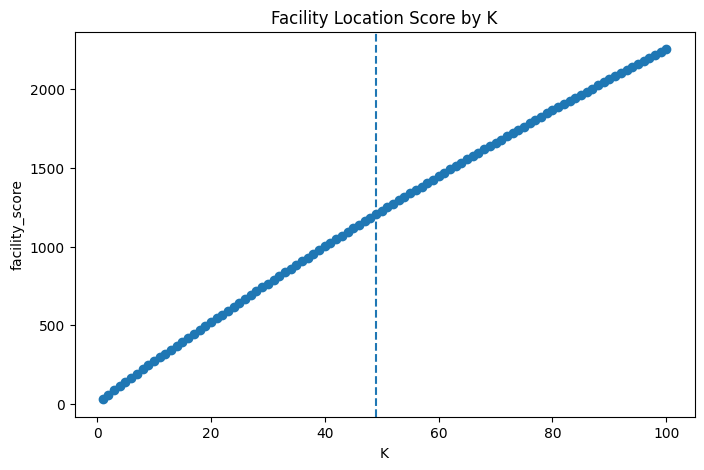

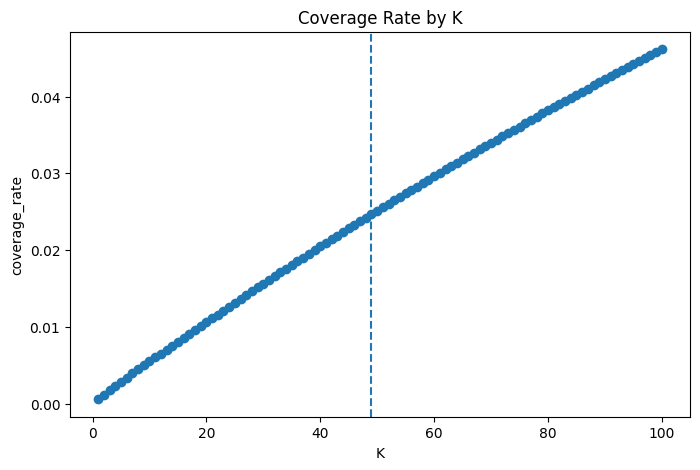

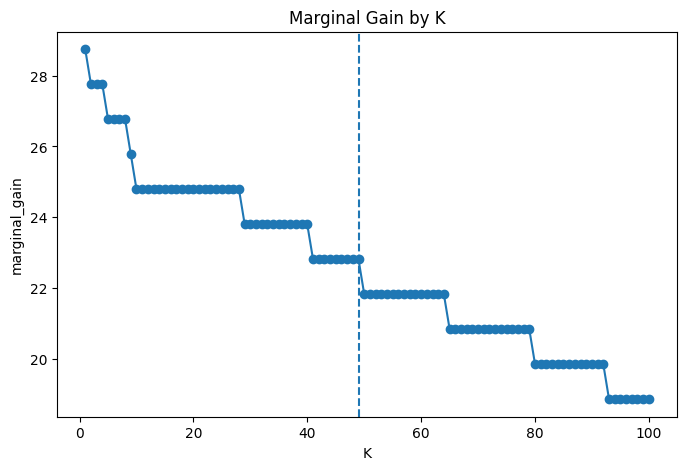

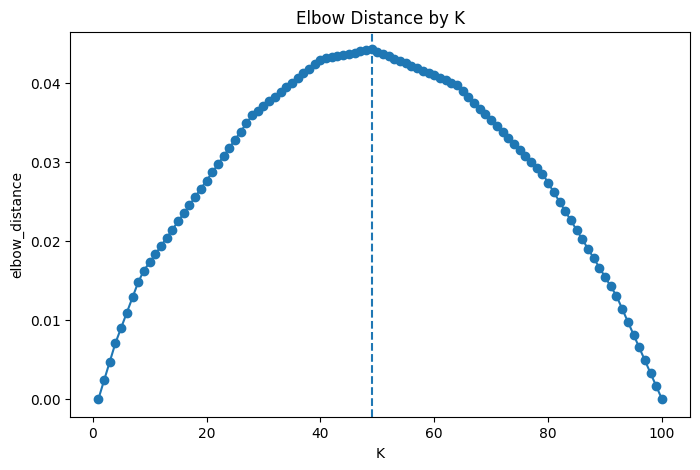

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(
    progress["K"],
    progress["facility_score"],
    marker="o"
)
plt.axvline(best_k, linestyle="--")
plt.title("Facility Location Score by K")
plt.xlabel("K")
plt.ylabel("facility_score")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    progress["K"],
    progress["coverage_rate"],
    marker="o"
)
plt.axvline(best_k, linestyle="--")
plt.title("Coverage Rate by K")
plt.xlabel("K")
plt.ylabel("coverage_rate")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    progress["K"],
    progress["marginal_gain"],
    marker="o"
)
plt.axvline(best_k, linestyle="--")
plt.title("Marginal Gain by K")
plt.xlabel("K")
plt.ylabel("marginal_gain")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    progress["K"],
    progress["elbow_distance"],
    marker="o"
)
plt.axvline(best_k, linestyle="--")
plt.title("Elbow Distance by K")
plt.xlabel("K")
plt.ylabel("elbow_distance")
plt.show()

In [12]:
best_selected_j_df.to_csv(
    "../DATA/PROCESS/facility_location_best_selected_j.csv",
    index=False
)

progress.to_csv(
    "../DATA/PROCESS/facility_location_k_experiment.csv",
    index=False
)

# 1. Facility Location 기반 후보지 집합 최적화

이전 단계까지는 개별 후보지 (j)가 특정 혼잡 지역 (h)와 얼마나 유사한지를 기준으로 후보를 선별하였다.

그러나 단순히 유사도가 높은 후보를 개별적으로 선택하면, 서로 비슷한 후보가 반복적으로 선택될 수 있다. 따라서 본 단계에서는 개별 후보의 점수보다 **전체 혼잡 지역 (H)를 가장 잘 대표하는 후보지 집합 (S)** 를 선택하는 것을 목표로 설정하였다.

---

# 2. 목적 함수

본 단계에서는 Facility Location 목적 함수를 사용하였다.

[
F(S) = \sum_{i \in H} \max_{j \in S} sim(i,j)
]

| 기호         | 의미                      |
| ---------- | ----------------------- |
| (H)        | 혼잡 지역 집합                |
| (S)        | 선택된 후보지 집합              |
| (sim(i,j)) | 혼잡 지역 (i)와 후보지 (j)의 유사도 |

본 분석에서는 이전 단계에서 이미 소비 맥락, 시간 차이, 로컬 상권 거리 기준을 통과한 후보만 남겼기 때문에, Facility Location의 유사도 (sim(i,j))는 도시 기능 유사도인 `x_sim`으로 정의하였다.

---

# 3. 입력 데이터

Facility Location 최적화에는 다음 데이터를 사용하였다.

| 데이터                        | 의미                            |
| -------------------------- | ----------------------------- |
| `best_candidate_df`        | 혼잡 지역 (H)와 후보지 (J) 간의 후보 pair |
| `final_candidate_local_df` | 로컬 상권 거리 필터링까지 통과한 최종 후보지     |
| `h_index`                  | 혼잡 지역 index                   |
| `j_index`                  | 후보지 index                     |
| `x_sim`                    | 도시 기능 유사도                     |
| `c_sim_scaled`             | 소비 맥락 유사도                     |
| `time_diff`                | 주기성을 반영한 시간 차이                |

로컬 상권 필터를 통과한 후보만 사용하기 위해 `final_candidate_local_df["j_index"]`에 포함된 후보만 남겼다.

---

# 4. 최적화 전 후보 규모

최적화 입력 데이터의 규모는 다음과 같다.

| 항목        |      개수 |
| --------- | ------: |
| 혼잡 지역 (H) |  49,263 |
| 후보 지역 (J) |  51,880 |
| 후보 pair   | 257,300 |

즉, 49,263개의 혼잡 지역에 대해 51,880개의 후보지가 연결되어 있으며, 전체 후보 관계는 257,300개이다.

---

# 5. Greedy Selection 방식

Facility Location 목적 함수는 후보 집합 (S)가 커질수록 값이 증가하지만, 이미 잘 대표되고 있는 혼잡 지역에 대해 유사한 후보를 추가하는 경우 추가 이득은 작아진다.

따라서 각 단계에서 다음 값을 계산하였다.

[
\Delta(j \mid S)
================

F(S \cup {j}) - F(S)
]

즉, 후보 (j)를 새로 추가했을 때 전체 Facility Location score가 얼마나 증가하는지를 의미한다.

매 단계에서 marginal gain이 가장 큰 후보를 선택하였다.

---

# 6. K 선택 방식

후보지 개수 (K)를 임의로 정하지 않기 위해, (K=1)부터 (K=100)까지 greedy selection을 수행하였다.

이후 Facility Location score 곡선의 elbow point를 이용해 최적 (K)를 선택하였다.

Elbow point는 다음과 같이 정의하였다.

1. (K)와 Facility Location score를 0~1 범위로 정규화한다.
2. 선형 증가 기준선과 실제 score 곡선의 차이를 계산한다.
3. 이 차이가 가장 큰 지점을 최적 (K)로 선택한다.

이 방식은 별도의 임의 가중치나 threshold 없이, score 증가의 diminishing return이 가장 뚜렷하게 나타나는 지점을 선택한다는 장점이 있다.

---

# 7. 최적 K 결과

실험 결과 최적 (K)는 다음과 같이 도출되었다.

| 항목                      |        값 |
| ----------------------- | -------: |
| 최적 (K)                  |       49 |
| Facility Location score | 1,206.80 |
| covered_h_count         |    1,217 |
| coverage_rate           |   0.0247 |
| avg_best_sim            |   0.0245 |
| marginal_gain           |    22.80 |
| coverage_gain           |       23 |
| coverage_gain_rate      | 0.000467 |
| elbow_distance          |   0.0442 |

따라서 최종적으로 49개의 후보지를 대표 후보 집합으로 선택하였다.

---

# 8. 결과 해석

최적화 결과, 전체 후보지 51,880개 중 49개가 대표 후보지로 선택되었다.

이 49개 후보지는 단순히 개별 similarity가 높은 후보가 아니라, 전체 혼잡 지역 집합을 기준으로 추가 대표성이 가장 큰 후보들이 순차적으로 선택된 결과이다.

즉, 각 후보지는 다음 기준을 만족한다.

```text
이미 선택된 후보들이 잘 설명하지 못하는 혼잡 지역을
추가로 가장 많이 대표하는 후보
```

따라서 최종 후보 집합은 중복적인 후보 선택을 줄이고, 서로 다른 혼잡 패턴을 대표하는 후보지들로 구성된다.

---

# 9. 최종 출력 데이터

최종 선택된 후보지는 `best_selected_j_df`로 저장하였다.

이 데이터에는 다음 정보가 포함된다.

| 컬럼                     | 의미                        |
| ---------------------- | ------------------------- |
| `selection_order`      | greedy selection에서 선택된 순서 |
| `j_index`              | 후보지 index                 |
| `위도`                   | 후보지 위도                    |
| `경도`                   | 후보지 경도                    |
| `nearest_local_dist_m` | 가장 가까운 로컬 상권까지 거리         |
| `nearest_local_상권명`    | 가장 가까운 로컬 상권명             |
| `nearest_local_자치구`    | 가장 가까운 로컬 상권의 자치구         |
| `covered_h_count`      | 해당 후보지가 커버하는 혼잡 지역 수      |
| `avg_x_sim`            | 평균 도시 기능 유사도              |
| `avg_c_sim_scaled`     | 평균 소비 맥락 유사도              |
| `avg_rank`             | 평균 nearest neighbor 순위    |
| `avg_time_diff`        | 평균 시간 차이                  |

---

# 10. 의의

본 단계는 후보지 추천을 단순 ranking 문제가 아니라, **전체 혼잡 지역을 대표하는 후보 집합 선택 문제**로 전환했다는 점에서 의미가 있다.

단순 상위 점수 후보를 선택하는 방식은 특정 지역이나 특정 유형의 후보가 반복될 가능성이 크지만, Facility Location 기반 방식은 전체 혼잡 지역에 대한 대표성과 커버리지를 고려한다.

따라서 최종 49개 후보지는 이후 정책 제안, 클러스터링, 수용여력 분석, 대표 hidden spot 선정의 핵심 입력으로 활용할 수 있다.
